# Residual Analysis — Multiple Linear Regression

This notebook analyzes the residuals produced by the
Multiple Linear Regression model.

### Objectives

- Calculate and inspect residuals
- Analyze residual distribution
- Examine residuals against predicted values
- Check for potential heteroscedasticity
- Examine the normality of residuals
- Investigate multicollinearity among predictors
- Identify potential influential observations

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from src.linear_regression import MultipleLinearRegression

In [2]:
df = pd.read_csv("../data/Advertising.csv")

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
model = MultipleLinearRegression()

model.fit(X_train, y_train)

In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Residuals

A residual represents the difference between an observed
target value and the value predicted by the model.

eᵢ = yᵢ - ŷᵢ

In [6]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

In [7]:
train_residuals.head()

79     1.311725
197    0.126623
38     0.044667
24     1.499898
122   -1.895621
Name: Sales, dtype: float64

In [8]:
residual_summary = pd.Series(train_residuals).describe()

residual_summary

count    1.600000e+02
mean    -6.877832e-15
std      1.649892e+00
min     -8.926524e+00
25%     -8.309037e-01
50%      2.613420e-01
75%      1.142675e+00
max      2.811377e+00
Name: Sales, dtype: float64

In [9]:
print("Mean residual:", train_residuals.mean())
print("Median residual:", train_residuals.median())
print("Std residual:", train_residuals.std())

Mean residual: -6.877831637552845e-15
Median residual: 0.26134197710099016
Std residual: 1.6498917587767419


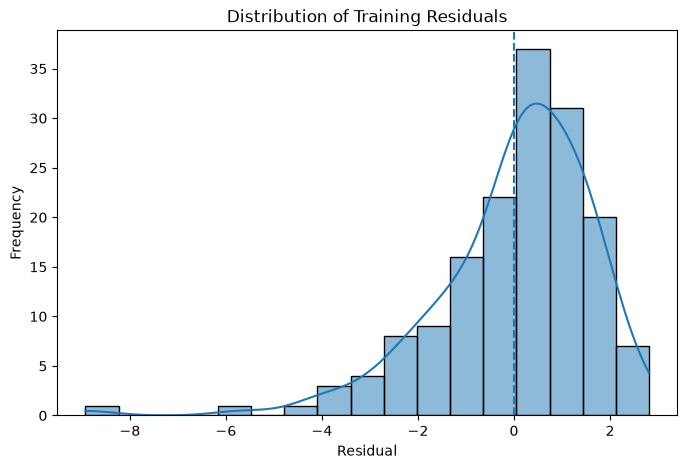

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    train_residuals,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Training Residuals")

plt.show()

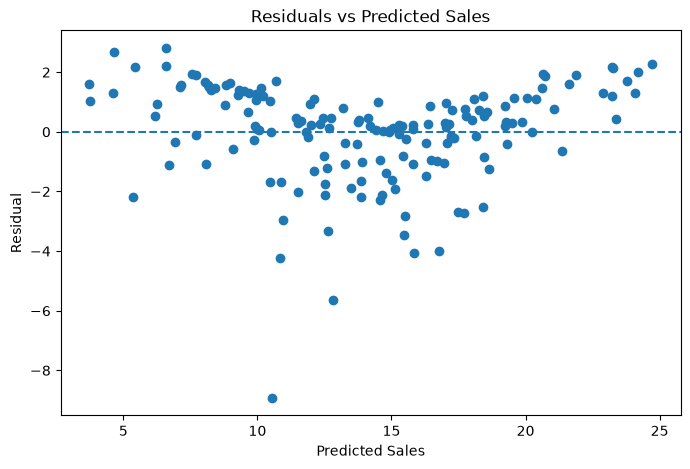

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_train_pred,
    train_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sales")

plt.show()


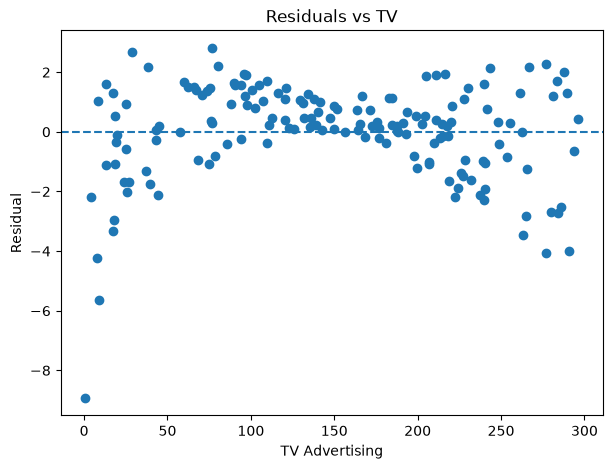

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_train["TV"],
    train_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("TV Advertising")
plt.ylabel("Residual")
plt.title("Residuals vs TV")

plt.show()

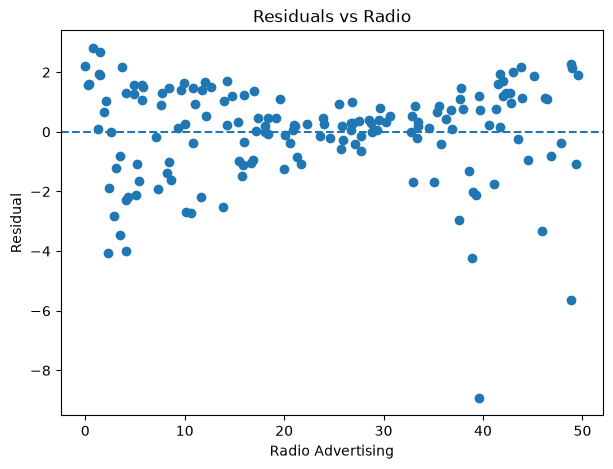

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_train["Radio"],
    train_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Radio Advertising")
plt.ylabel("Residual")
plt.title("Residuals vs Radio")

plt.show()

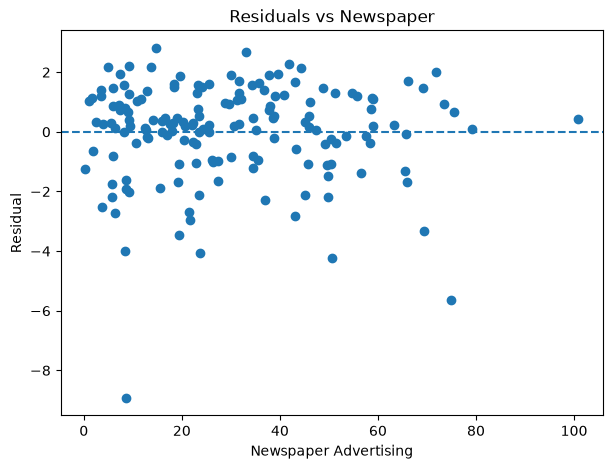

In [14]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_train["Newspaper"],
    train_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Newspaper Advertising")
plt.ylabel("Residual")
plt.title("Residuals vs Newspaper")

plt.show()